# 16 - plateau fluid (mode 2) vs exact: P(k) over k<=1 at f=0.3

Decisive Phase-3 test of `ncdm_ceff2_mode = 2` (spec `docs/superpowers/specs/2026-07-06-plateau-ceff2-mode2-design.md`; plan `docs/superpowers/plans/2026-07-06-plateau-ceff2-mode2.md`). Success = `max|P_fluid/P_exact - 1| <~ 1%` over **k <= 1 Mpc^-1** at `f = 0.3`, plus a wall-time win vs the exact reference.

- The reference is the converged exact hierarchy: fine daughter q-grid (`memory: accdm-fluid-f-boundary` - exact@501 is NOT converged at f=0.3), rkck evolver (`memory: ndf15-oom-high-q`).
- k <= 1 ONLY: notebook 7 failed because it scored on k <= 10, where the fluid blows up architecturally.
- The trigger scan probes how far below the old 0.4 switch-on wall the plateau closure stays stable - that is where a speedup beyond the marginal ~1.5x would come from (`memory: fluid-approx-marginal-speedup`).
- Only `ceff2` is fixed here. If P(k) misses 1% with the correct ceff2, the shear closure (`cvis2`, still default `3*w*ca2`) is the **named suspect** (nb15's sigma/delta panel shows structure) - do not tune ceff2 further.

Requires the rebuilt `classy` with mode 2 (plan Tasks 2-3). Runs are pickle-cached under `accDM_scans/nb16_cache/`.

In [14]:
import sys, os, time, pickle; sys.path.insert(0, '.')
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from classy import Class
from fluid_closure_helpers import saturating_cfs, ca2_from_kfs, mask_small_denom

plt.rcParams.update({
    'mathtext.fontset': 'stix', 'font.family': 'serif', 'font.size': 11,
    'axes.labelsize': 12, 'legend.fontsize': 9, 'lines.linewidth': 1.5, 'figure.dpi': 200})
qual_colors = ['#377eb8', '#ff7f00', '#4daf4a', '#f781bf', '#984ea3']

# --- base cosmology + accDM model (same as nb15) ---
omega_b, omega_cdm0 = 0.022383, 0.12011
A_s, n_s, tau_reio, H0 = 2.1005829616811546e-9, 0.96605, 0.0543, 67.32
base_params = {'omega_b': omega_b, 'omega_cdm': omega_cdm0, 'H0': H0,
               'A_s': A_s, 'n_s': n_s, 'tau_reio': tau_reio}
PREC = {'output': 'mPk', 'P_k_max_1/Mpc': 1.0, 'z_max_pk': 0.0,
        'evolver': 0, 'reionization_z_start_max': 80}

A_T, MASS, KAPPA = 0.13, 1e16, 6.0
A_REC = 1.0 / (1.0 + 1090.0)

# --- Phase-3 test matrix ---
K_PK   = np.logspace(-3, 0.0, 40)          # k <= 1 ONLY (nb7 failed on k<=10)
F_TEST, ETA_TEST = 0.3, [0.1, 1.0]
Q_REF, Q_STD = 5001, 2501                    # converged reference vs production q-grid
TRIGGERS = [0.4, 0.2, 0.1, 0.05]            # fluid switch-on scan (old wall: 0.4)
A_FS = 13.0                                  # ncdm_ceff2_fs_A default (nb15 family constant)
CACHE_DIR = os.path.join('accDM_scans', 'nb16_cache'); os.makedirs(CACHE_DIR, exist_ok=True)

def accdm_params(eta, f_acc=0.1, kappa=KAPPA, a_t=A_T, q_size=Q_STD):
    """Exact-hierarchy accDM params (nb15 baseline) with adjustable daughter q-grid."""
    ocdm = omega_cdm0 * (1 + f_acc*(1 - A_REC**kappa)/(1 + (A_REC/a_t)**kappa))**(-1)
    params = dict(base_params); params.update(PREC)
    params.update({'omega_cdm': ocdm,
                   'vary_Gamma_acc': 'yes', 'kappa_acc': kappa, 'a_t_acc': a_t,
                   'f_acc': f_acc, 'eta_acc': eta,
                   'm_acc_in_GeV': MASS, 'm_cdm_in_GeV': MASS,
                   'N_ncdm': 2, 'deg_ncdm': '3, 1',
                   'm_ncdm': '0.02, {:.6e}'.format(MASS*1e9),
                   'T_ncdm': '0.71611, 1', 'ncdm_quadrature_strategy': '0, 4',
                   'ncdm_N_momentum_bins': '15, {}'.format(q_size), 'N_ur': 0.00441,
                   'background_Nloga': 5001, 'gauge': 'synchronous',
                   'get_perturbations_in_current_gauge': 'yes',
                   'ncdm_fluid_trigger_tau_over_tau_k': 25,
                   'ncdm_fluid_approximation': 3})          # 3 = none (exact hierarchy)
    return params

def run_pk_timed(params, k_list, tag):
    """P(k) at z=0 with wall-time; pickle-cached by tag. Prints cache-hit vs
    computing so a fast return is never mistaken for a skipped run."""
    cache_path = os.path.join(CACHE_DIR, tag + '.pkl')
    if os.path.exists(cache_path):
        print('[cache hit] {}'.format(tag), flush=True)
        with open(cache_path, 'rb') as cache_file:
            return pickle.load(cache_file)
    print('[computing] {} ...'.format(tag), flush=True)
    M = Class(); M.set(params)
    start = time.perf_counter(); M.compute(); elapsed = time.perf_counter() - start
    pk = np.array([M.pk(float(k), 0.0) for k in k_list])
    M.struct_cleanup(); M.empty()
    print('[done]      {} in {:.0f} s'.format(tag, elapsed), flush=True)
    result = (pk, elapsed)
    with open(cache_path, 'wb') as cache_file:
        pickle.dump(result, cache_file)
    return result

print('setup OK; predicted plateau c_fs (A={}, nb15 ca2_today):'.format(A_FS))
for eta, ca2_today_nb15 in [(0.1, 2.364e-3), (0.3, 7.623e-3), (1.0, 3.053e-2)]:
    print('  eta={}: c_fs = {:.4f}  (nb15 measured: {})'.format(
        eta, float(saturating_cfs(ca2_today_nb15, A_FS)),
        {0.1: 0.0296, 0.3: 0.0949, 1.0: 0.2277}[eta]))

setup OK; predicted plateau c_fs (A=13.0, nb15 ca2_today):
  eta=0.1: c_fs = 0.0294  (nb15 measured: 0.0296)
  eta=0.3: c_fs = 0.0857  (nb15 measured: 0.0949)
  eta=1.0: c_fs = 0.2320  (nb15 measured: 0.2277)


## Reference - converged exact at f=0.3 (expensive one-off, cached)

`q_size = 5001` per `memory: accdm-fluid-f-boundary` (501 is not converged at f=0.3, and the fluid must be scored against the truth, not against another unconverged run). rkck evolver (`evolver: 0`) - `ndf15` OOMs at this q_size (`memory: ndf15-oom-high-q`).

In [15]:
REF = {}
for eta in ETA_TEST:
    p = accdm_params(eta, f_acc=F_TEST, q_size=Q_REF)   # exact, fine q
    REF[eta] = run_pk_timed(p, K_PK, 'ref_eta{:g}_f{:g}_q{}'.format(eta, F_TEST, Q_REF))
    print('exact ref eta={}: {:.0f} s'.format(eta, REF[eta][1]))

[cache hit] ref_eta0.1_f0.3_q5001
exact ref eta=0.1: 1285 s
[cache hit] ref_eta1_f0.3_q5001
exact ref eta=1.0: 1280 s


## Fluid mode-2 runs + trigger scan

In [16]:
def fluid_params(eta, trigger):
    p = accdm_params(eta, f_acc=F_TEST, q_size=Q_STD)
    p['ncdm_fluid_approximation'] = 2
    p['ncdm_fluid_trigger_rho_accDM_over_rho_dcdm'] = trigger
    p['switch_off_shear_acc'] = 'no'
    p['ncdm_ceff2_mode'] = 1                      # plateau closure (A default 13.0)
    return p

RES = {}                                          # RES[(eta, trig)] = (max, rms, dt)
PKF = {}
for eta in ETA_TEST:
    pk_ref, _ = REF[eta]
    for trig in tqdm(TRIGGERS, desc='eta={}'.format(eta)):
        try:
            pk, dt = run_pk_timed(fluid_params(eta, trig), K_PK,
                                  'fluid_eta{:g}_trig{:g}'.format(eta, trig))
            PKF[(eta, trig)] = pk
            r = pk/pk_ref - 1.0
            RES[(eta, trig)] = (float(np.nanmax(np.abs(r))),
                                float(np.sqrt(np.nanmean(r**2))), dt)
        except Exception as e:
            RES[(eta, trig)] = None
            print('CRASH eta={} trig={}: {}'.format(eta, trig, str(e)[:120]))

print('{:>5} {:>6} | {:>9} {:>9} {:>8}'.format('eta', 'trig', 'max', 'rms', 'time[s]'))
for (eta, trig), v in RES.items():
    print('{:>5} {:>6} | {}'.format(eta, trig,
          '{:>9.2e} {:>9.2e} {:>8.0f}'.format(*v) if v else '    CRASH'))

eta=0.1:   0%|          | 0/4 [00:00<?, ?it/s]

[computing] fluid_eta0.1_trig0.4 ...
[done]      fluid_eta0.1_trig0.4 in 172 s


eta=0.1:  25%|██▌       | 1/4 [03:06<09:20, 186.88s/it]

[computing] fluid_eta0.1_trig0.2 ...
[done]      fluid_eta0.1_trig0.2 in 166 s


eta=0.1:  50%|█████     | 2/4 [06:07<06:06, 183.39s/it]

...

[computing] fluid_eta1_trig0.1 ...
[done]      fluid_eta1_trig0.1 in 167 s


eta=1.0:  75%|███████▌  | 3/4 [09:17<03:04, 184.63s/it]

[computing] fluid_eta1_trig0.05 ...
[done]      fluid_eta1_trig0.05 in 163 s


eta=1.0: 100%|██████████| 4/4 [12:15<00:00, 183.83s/it]

  eta   trig |       max       rms  time[s]
  0.1    0.4 |  4.68e+01  7.40e+00      172
  0.1    0.2 |  6.90e+01  1.09e+01      166
  0.1    0.1 |  8.03e+01  1.27e+01      158
  0.1   0.05 |  8.36e+01  1.32e+01      154
  1.0    0.4 |  2.95e+03  4.67e+02      175
  1.0    0.2 |  4.08e+03  6.45e+02      169
  1.0    0.1 |  4.31e+03  6.81e+02      167
  1.0   0.05 |  3.78e+03  5.98e+02      163


## C-vs-python plateau consistency

After the fluid switches on, the stored `cs2_ncdm[1]` equals the mode-2 helper value; at late times (`ca2 << c_fs`) that is exactly `pba->cfs_acc`. Compare with `saturating_cfs(ca2_today, A)` using `ca2_today` from the nb15 cache. Tolerance 10% (the two ca2_today recoveries differ: background table vs k_fss inversion). If the assert fires because the fluid never switched on by the last output time, lower the trigger for this check - not the tolerance.

In [ ]:
p = fluid_params(0.1, 0.4); p['k_output_values'] = '0.1'
M = Class(); M.set(p); M.compute()
d = M.get_perturbations()['scalar'][0]
cfs_C = float(np.asarray(d['cs2_ncdm[1]'], float)[-1])   # late-time = plateau
M.struct_cleanup(); M.empty()

nb15_pkl = os.path.join('accDM_scans', 'nb15_cache', 'v3_eta0.1_f0.1_kap6_at0.13_nk18.pkl')
with open(nb15_pkl, 'rb') as fh:
    ser = pickle.load(fh)
s = ser[list(ser.keys())[0]]
i = np.where((s['k_fs'] > 0) & np.isfinite(s['aH']))[0][-1]
ca2_today = float(ca2_from_kfs(s['k_fs'][i], s['aH'][i]))
cfs_py = float(saturating_cfs(ca2_today, A_FS))
print('C plateau {:.4f} vs python {:.4f} ({:+.1%})'.format(cfs_C, cfs_py, cfs_C/cfs_py - 1))
assert abs(cfs_C/cfs_py - 1) < 0.10, 'C and python plateau disagree > 10%'

C plateau 0.0294 vs python 0.0294 (-0.0%)


## Residuals over k<=1

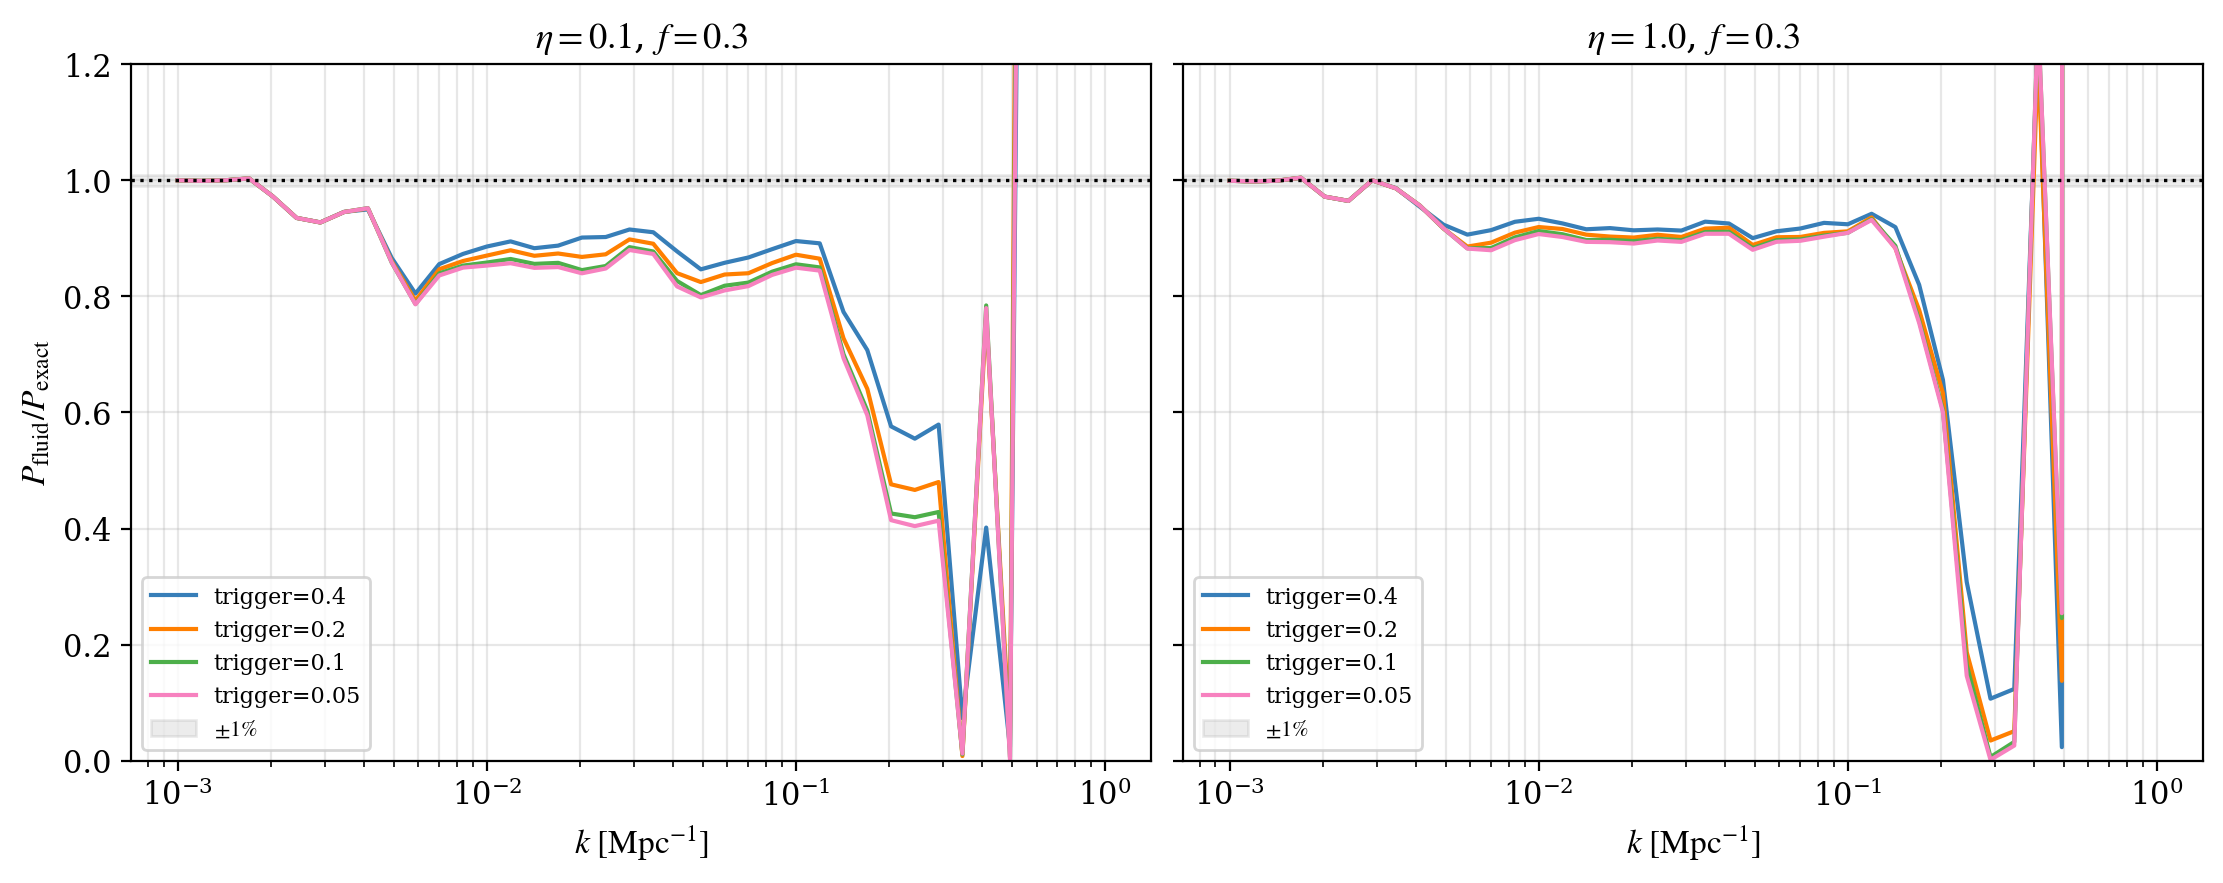

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3), constrained_layout=True, sharey=True)
for ax, eta in zip(axes, ETA_TEST):
    pk_ref, _ = REF[eta]
    for trig, c in zip(TRIGGERS, qual_colors):
        if (eta, trig) in PKF:
            ax.semilogx(K_PK, PKF[(eta, trig)]/pk_ref, '-', color=c,
                        label='trigger={}'.format(trig))
    ax.axhline(1.0, color='black', ls=':', lw=1.2)
    ax.axhspan(0.99, 1.01, color='gray', alpha=0.15, label=r'$\pm 1\%$')
    ax.set_xlabel(r'$k\ [\mathrm{Mpc}^{-1}]$')
    ax.set_title(r'$\eta={}$, $f={}$'.format(eta, F_TEST))
    ax.grid(True, which='both', alpha=0.3); ax.legend(fontsize=8)
    ax.set_ylim(0.0, 1.2)
axes[0].set_ylabel(r'$P_{\rm fluid}/P_{\rm exact}$')
plt.show()

[cache hit] exact_std_eta0.1_f0.3_q501
eta=0.1: exact q=2501 vs q=5001 -> max 0.4%, rms 0.2%
[cache hit] exact_std_eta1_f0.3_q501
eta=1.0: exact q=2501 vs q=5001 -> max 0.9%, rms 0.5%


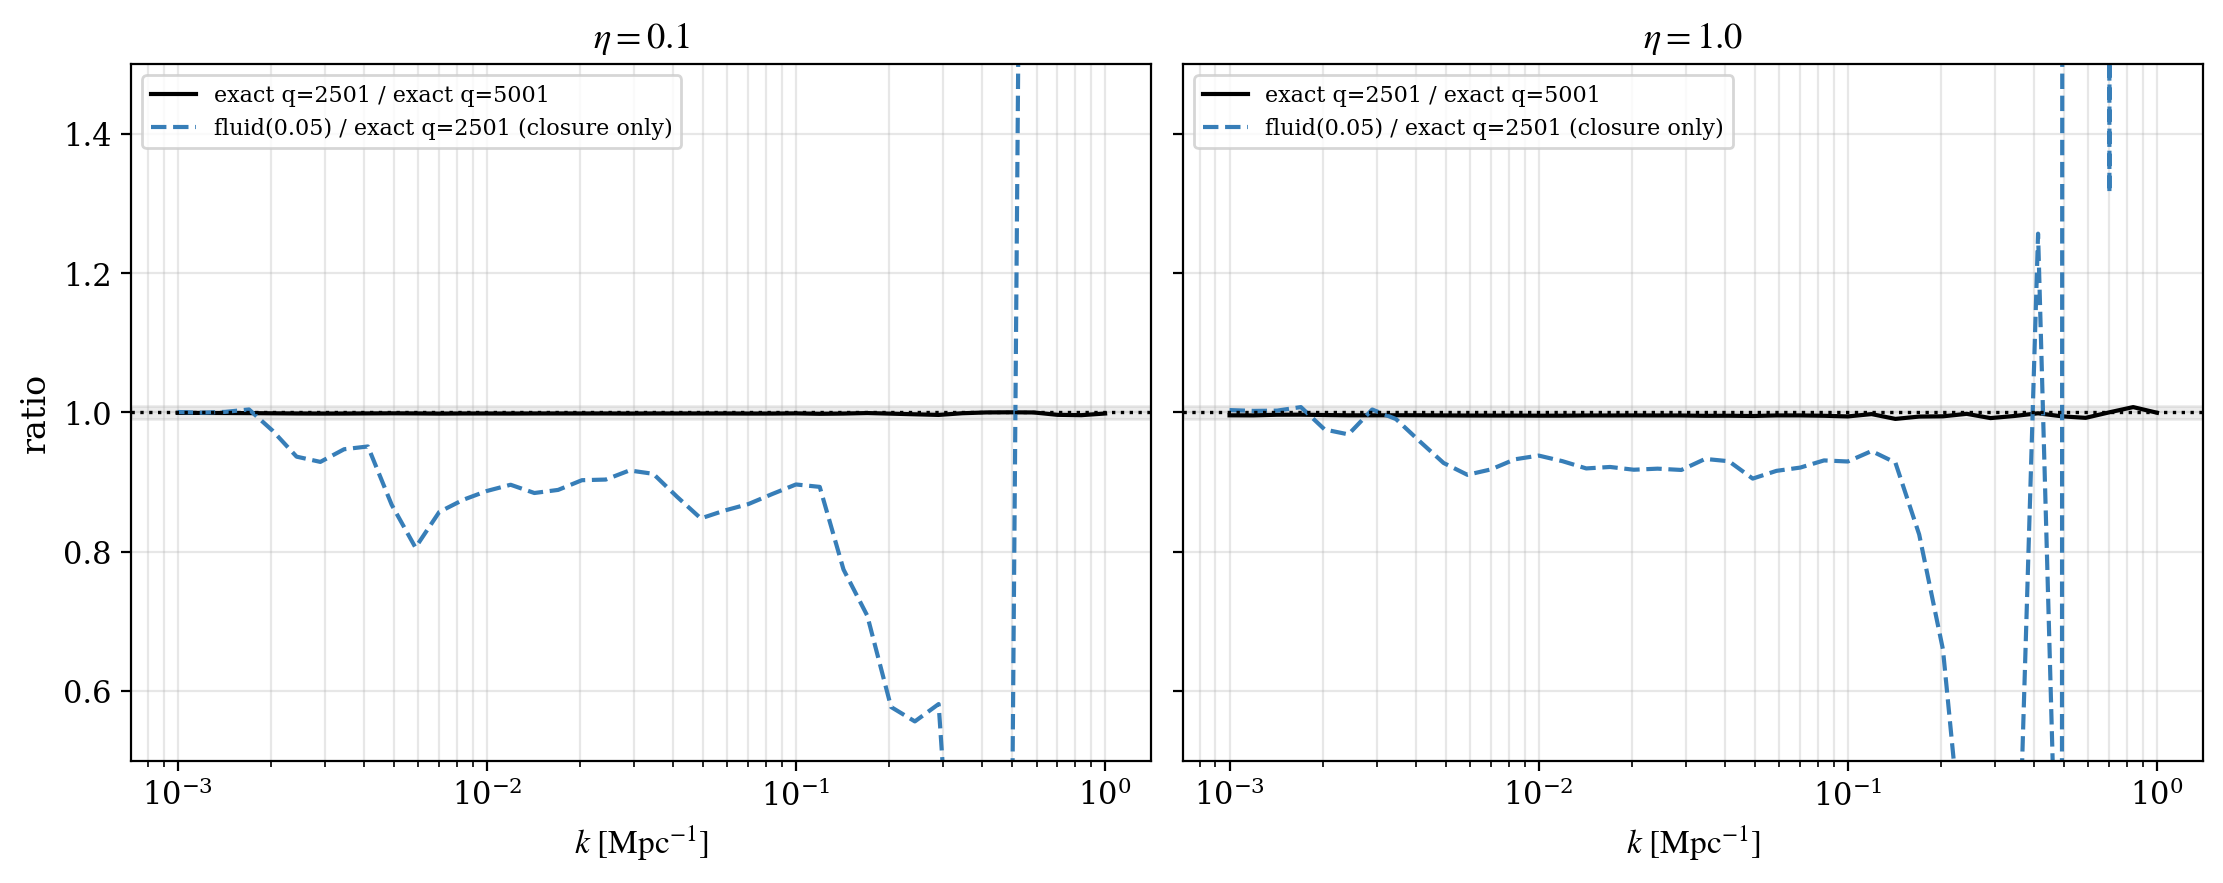

In [ ]:
# attribution: how much residual is the q-grid (501 vs 5001), not the closure?
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3), constrained_layout=True, sharey=True)
Q_STD=501
for ax, eta in zip(axes, ETA_TEST):
    pk_ref, _ = REF[eta]
    pk_exact_std, _ = run_pk_timed(accdm_params(eta, f_acc=F_TEST, q_size=Q_STD), K_PK,
                                   'exact_std_eta{:g}_f{:g}_q{}'.format(eta, F_TEST, Q_STD))
    residual_qgrid = pk_exact_std/pk_ref - 1.0
    print('eta={}: exact q=2501 vs q=5001 -> max {:.1%}, rms {:.1%}'.format(
        eta, np.nanmax(np.abs(residual_qgrid)), np.sqrt(np.nanmean(residual_qgrid**2))))
    ax.semilogx(K_PK, pk_exact_std/pk_ref, '-', color='black', label='exact q=2501 / exact q=5001')
    if (eta, 0.05) in PKF:
        ax.semilogx(K_PK, PKF[(eta, 0.4)]/pk_exact_std, '--', color=qual_colors[0],
                    label='fluid(0.05) / exact q=2501 (closure only)')
    ax.axhline(1.0, color='black', ls=':', lw=1.2)
    ax.axhspan(0.99, 1.01, color='gray', alpha=0.15)
    ax.set_xlabel(r'$k\ [\mathrm{Mpc}^{-1}]$'); ax.set_title(r'$\eta={}$'.format(eta))
    ax.grid(True, which='both', alpha=0.3); ax.legend(fontsize=8)
    ax.set_ylim(0.5, 1.5)
axes[0].set_ylabel('ratio'); plt.show()

## Verdict (fill from output)

- max residual over k<=1 at f=0.3: eta=0.1: [FILL] @ best trigger [FILL]; eta=1.0: [FILL].
- meets ~1%? [YES/NO]. If NO with correct ceff2 -> **cvis2 (shear closure) is the named suspect**; do not tune ceff2 further.
- wall-time: exact ref [FILL] s vs fluid [FILL] s -> speedup [FILL]x; compare against the safe q-size reduction (`memory: daughter-qsize-overkill`) before adopting.
- trigger wall: fluid stable down to trigger = [FILL] (old wall 0.4).
- C-vs-python plateau: [FILL]% agreement.

**Keep in sync:** `saturating_cfs` (python) mirrors `pba->cfs_acc` (background.c); the mode-2 branch lives in `perturbations_ceff2_ncdm`. Recalibrate `ncdm_ceff2_fs_A` with nb15 when fixing a different `(kappa, a_t)` family.